<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi
</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 10</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>


<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 10</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- **Aufgabe 10_01: Gleichverteilung auf der Kugeloberfläche**
- Aufgabe 10_02: Monte Carlo-Integration I 
- Aufgabe 10_03: Monte Carlo-Integration II
- Aufgabe 10_04: Bonus Chaos 

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgabe 1: Gleichverteilung auf der Kugeloberfläche</td>


Ziel dieser Aufgabe ist es, gleichverteilte Koordinaten auf der Oberfläche einer 3 dimensionalen Kugel zu erzeugen (2-Sphäre).

Da jeder Punkt auf der Oberfläche durch Angabe zweier Winkel - des Azimutwinkels $\phi \in [0, 2\pi$] und des Polarwinkels $\theta \in [0,\pi]$ - beschrieben werden kann, könnte man sich vorstellen, das um gleichverteilte Koordinten auf der Kugeloberfläche zu Samplen es reichen würde diese beiden Winkel gleichverteilt zu samplen.

## a) 
Gehen Sie exakt so vor uns samplen Sie auf diese Weise N Punkte (z.B. N = 10.000) auf der 2-Sphäre.

Nun wollen wir dieses Sampling einem Spektraltest unterziehen. Plotten Sie dazu die erzeugten Punkte auf geeignete Weise in einem 3D-Plot. **Sind die Punkte tatsächlich gleichverteilt? Schildern Sie, was Sie sehen.**

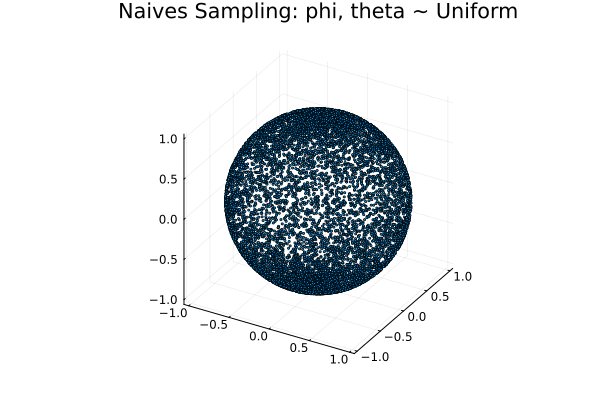

In [16]:
using Random
using Plots


N = 10_000

# Naives Sampling: phi und theta jeweils gleichverteilt
phi   = 2π .* rand(N)          # Azimutwinkel in [0, 2*pi]
theta = π  .* rand(N)          # Polarwinkel  in [0, pi]

x = sin.(theta) .* cos.(phi)
y = sin.(theta) .* sin.(phi)
z = cos.(theta)

scatter3d(x, y, z, markersize=1.2, legend=false, camera=(30,30),
          title="Naives Sampling: phi, theta ~ Uniform")



**Beobachtung:** Nein, die Punkte sind *nicht* gleichverteilt auf der Kugeloberfläche!

Man sieht deutlich, dass sich die Punkte an den Polen ($\theta = 0$ und $\theta = \pi$, also den "Nord-" und "Südpolen" der Kugel) häufen, während der "Äquator" vergleichsweise dünn besetzt ist.

**Grund:** Das Flächenelement auf der Kugeloberfläche in Kugelkoordinaten lautet

$$dA = \sin\theta \, d\theta \, d\phi.$$

Sampled man $\theta$ gleichverteilt in $[0,\pi]$, so wird der Faktor $\sin\theta$ *nicht* berücksichtigt. In der Nähe der Pole ($\theta \approx 0$ oder $\theta \approx \pi$) ist $\sin\theta$ klein, d.h. ein kleines Intervall $d\theta$ entspricht dort einer sehr kleinen Fläche — trotzdem werden dort genauso viele $\theta$-Werte gesampelt wie am Äquator (wo $\sin\theta \approx 1$ und die Fläche pro $d\theta$ am größten ist). Dadurch werden die Pole überrepräsentiert.

## b) 
Im ersten Aufgabenteil sollte Ihnen aufgefallen sein, dass das gleichverteilte Sampling von $\phi$ und $\theta$ keine gleichverteilten Punkte auf der Kugeloberfläche liefert. 

Wiederholen Sie nun die Schritte aus Teil a), samplen jedoch jetzt die $z$-Komponente ($z \in [-1,1])$ und den Azimutwinkel $\phi$. 

Überzeugen Sie sich mit Hilfe eines Spektraltests von der Gleichverteilung der so gesampleten Punkte auf der Sphäre. **Können Sie erklären, warum dieses Vorgehen im vergleich zum anderen funktioniert?**

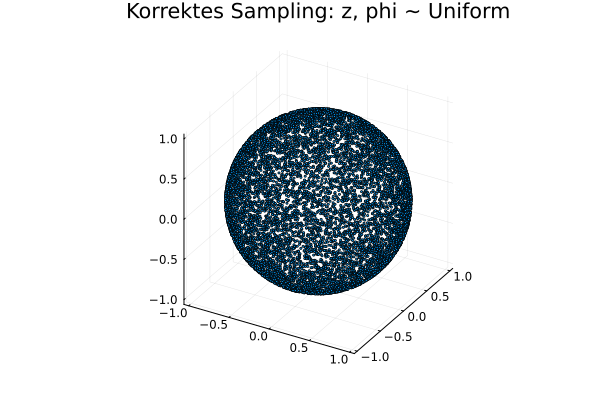

In [2]:
# Korrektes Sampling: z und phi gleichverteilt
z2   = 2 .* rand(N) .- 1        # z in [-1, 1], gleichverteilt
phi2 = 2π .* rand(N)            # phi in [0, 2*pi]

r  = sqrt.(1 .- z2.^2)
x2 = r .* cos.(phi2)
y2 = r .* sin.(phi2)

scatter3d(x2, y2, z2, markersize=1.2, legend=false, camera=(30,30),
          title="Korrektes Sampling: z, phi ~ Uniform")


**Beobachtung:** Jetzt sind die Punkte tatsächlich gleichverteilt auf der Kugeloberfläche — keine Häufung an den Polen mehr, die Punktdichte sieht überall gleich aus.

**Erklärung:** Wir nutzen die Substitution $z = \cos\theta$. Es gilt

$$dz = -\sin\theta \, d\theta \quad \Longrightarrow \quad dA = \sin\theta \, d\theta \, d\phi = -dz \, d\phi.$$

Das bedeutet: Das Flächenelement ist in den Variablen $(z, \phi)$ *konstant* (bis auf das Vorzeichen, das nur die Integrationsrichtung betrifft) — es hängt nicht mehr von $z$ ab! Sampled man also $z$ gleichverteilt in $[-1,1]$ und $\phi$ gleichverteilt in $[0, 2\pi)$, entspricht das direkt einer gleichverteilten Fläche auf der Sphäre. Der Faktor $\sin\theta$, der im Verfahren aus a) fehlte, wird hier automatisch durch die Variablensubstitution "absorbiert".

## c) Pseudo Code

Schreiben sie pseudo-code für die Funktion, die eine beliebige Anzahl an zufälligen Punkten auf einer Kugel generiert.

**Pseudocode:**

```
FUNCTION sample_sphere(N):
    points <- leere Liste

    FOR i = 1 TO N:
        phi <- ZufallszahlUniform(0, 2*pi)      # Azimutwinkel
        z   <- ZufallszahlUniform(-1, 1)        # z-Komponente
        r   <- sqrt(1 - z^2)                    # Radius des Breitenkreises

        x <- r * cos(phi)
        y <- r * sin(phi)
        # z bleibt wie gesampelt

        points.append( (x, y, z) )
    END FOR

    RETURN points
END FUNCTION
```

Wichtig ist, dass **nicht** der Polarwinkel $\theta$, sondern direkt die $z$-Komponente gleichverteilt gesampelt wird (zusammen mit dem Azimutwinkel $\phi$), damit die resultierenden Punkte tatsächlich gleichverteilt auf der Kugeloberfläche liegen (siehe Begründung in Teil b)).